## SECTION 1 — Load Mastery Estimates

**Why:** Recommendations are built entirely from the per-student per-skill mastery estimates produced by BKT. We never touch raw data here.

In [1]:
# Cell 1 — Load mastery estimates
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

mastery = pd.read_csv('../outputs/mastery_estimates.csv')

print("Mastery estimates loaded.")
print("Shape:", mastery.shape)
print("Students:", mastery['user_id'].nunique())
print("Skills:", mastery['skill_name'].nunique())
print(mastery.head())

Mastery estimates loaded.
Shape: (37019, 5)
Students: 3053
Skills: 92
   user_id            skill_name  mastery_prob  n_opportunities  correct_rate
0       14          Circle Graph      0.621239               12      0.250000
1       14  Equivalent Fractions      0.927885                6      0.333333
2       14      Finding Percents      0.206238                2      0.000000
3       14                Median      0.126352                4      0.000000
4       14            Percent Of      0.338310                6      0.166667


## SECTION 2 — Knowledge Gap Detection

**Why:** A "knowledge gap" is a skill a student has practiced but not mastered. Using the standard BKT mastery threshold of 0.8, any (student, skill) pair with `mastery_prob < 0.8` is flagged as a gap.

**Thesis note:** "A knowledge gap was defined as any knowledge component for which a learner's estimated mastery fell below the 0.8 threshold. This produced a per-learner profile of unmastered skills used as the basis for recommendation."

In [2]:
# Cell 2 — Flag knowledge gaps
MASTERY_THRESHOLD = 0.8

mastery['is_gap'] = mastery['mastery_prob'] < MASTERY_THRESHOLD

total_pairs = len(mastery)
total_gaps = mastery['is_gap'].sum()

print(f"Mastery threshold: {MASTERY_THRESHOLD}")
print(f"Total student-skill pairs: {total_pairs}")
print(f"Knowledge gaps (below threshold): {total_gaps} "
      f"({round(total_gaps/total_pairs*100, 1)}%)")

gaps_per_student = mastery[mastery['is_gap']].groupby('user_id').size()
print(f"\nAverage gaps per student: {gaps_per_student.mean():.1f}")
print(f"Students with at least one gap: {gaps_per_student.shape[0]}")

Mastery threshold: 0.8
Total student-skill pairs: 37019
Knowledge gaps (below threshold): 10426 (28.2%)

Average gaps per student: 4.3
Students with at least one gap: 2419


## SECTION 3 — Generate Personalized Recommendations (Scenario B)

**Why:** For each student, the personalized scenario recommends the skills they have NOT mastered, prioritized by how far below threshold they are (lowest mastery = highest priority).

**Thesis note:** "For each learner, the system generated a ranked list of recommended knowledge components, prioritizing those with the lowest estimated mastery."

In [3]:
# Cell 3 — Example recommendation for one student
def recommend_for_student(student_df, top_n=5):
    """Return the student's weakest unmastered skills, lowest mastery first."""
    gaps = student_df[student_df['is_gap']].copy()
    gaps = gaps.sort_values('mastery_prob', ascending=True)
    return gaps.head(top_n)

example_id = mastery['user_id'].iloc[0]
example = recommend_for_student(mastery[mastery['user_id'] == example_id])
print(f"Recommended skills to revisit for student {example_id}:")
print(example[['skill_name', 'mastery_prob', 'n_opportunities', 'correct_rate']])

Recommended skills to revisit for student 14:
         skill_name  mastery_prob  n_opportunities  correct_rate
3            Median      0.126352                4      0.000000
2  Finding Percents      0.206238                2      0.000000
5        Proportion      0.270100                2      0.000000
4        Percent Of      0.338310                6      0.166667
0      Circle Graph      0.621239               12      0.250000


In [4]:
# Cell 4 — Generate recommendations for all students
recommendations = []
for student_id, student_df in mastery.groupby('user_id'):
    recs = recommend_for_student(student_df, top_n=5)
    for rank, (_, row) in enumerate(recs.iterrows(), start=1):
        recommendations.append({
            'user_id': student_id,
            'rank': rank,
            'recommended_skill': row['skill_name'],
            'mastery_prob': row['mastery_prob'],
        })

recommendations_df = pd.DataFrame(recommendations)
print(f"Generated {len(recommendations_df)} recommendations "
      f"for {recommendations_df['user_id'].nunique()} students")
print(recommendations_df.head(10))

Generated 7770 recommendations for 2419 students
   user_id  rank      recommended_skill  mastery_prob
0       14     1                 Median      0.126352
1       14     2       Finding Percents      0.206238
2       14     3             Proportion      0.270100
3       14     4             Percent Of      0.338310
4       14     5           Circle Graph      0.621239
5    21825     1                 Median      0.536065
6    53167     1             Estimation      0.292421
7    53167     2  Ordering Real Numbers      0.403673
8    53167     3       Finding Percents      0.404668
9    53167     4                 Median      0.444226


## SECTION 4 — The Non-Personalized Baseline (Scenario A)

**Why:** Scenario A is the standard one-size-fits-all path: every student follows the same fixed sequence of skills regardless of what they already know. We define this as all skills ordered by overall difficulty (hardest first — lowest average mastery first).

The key question: **how much of this fixed path sends students to skills they have ALREADY mastered (wasted effort)?**

In [5]:
# Cell 5 — Define the fixed (non-personalized) sequence
skill_difficulty = mastery.groupby('skill_name')['mastery_prob'].mean().sort_values()
fixed_sequence = skill_difficulty.index.tolist()

print("Fixed learning sequence (first 10 skills, same for all students):")
for i, skill in enumerate(fixed_sequence[:10], start=1):
    print(f"  {i}. {skill}")

Fixed learning sequence (first 10 skills, same for all students):
  1. Angles on Parallel Lines Cut by a Transversal
  2. Simplifying Expressions positive exponents
  3. Percents
  4. Rotations
  5. Solving Systems of Linear Equations
  6. Angles - Obtuse, Acute, and Right
  7. Counting Methods
  8. Conversion of Fraction Decimals Percents
  9. Proportion
  10. Addition and Subtraction Integers


In [6]:
# Cell 6 — Measure wasted effort in the fixed path
results = []
for student_id, student_df in mastery.groupby('user_id'):
    student_skills = set(student_df['skill_name'])
    mastered = set(student_df[student_df['mastery_prob'] >= MASTERY_THRESHOLD]['skill_name'])

    fixed_for_student = [s for s in fixed_sequence if s in student_skills]
    wasted = [s for s in fixed_for_student if s in mastered]

    results.append({
        'user_id': student_id,
        'n_skills': len(fixed_for_student),
        'n_mastered_in_path': len(wasted),
        'pct_wasted': len(wasted) / len(fixed_for_student) * 100
                      if fixed_for_student else 0,
    })

waste_df = pd.DataFrame(results)
print("=== SCENARIO A (fixed path) wasted effort ===")
print(f"Average % of fixed path on already-mastered skills: "
      f"{waste_df['pct_wasted'].mean():.1f}%")
print(waste_df.head())

=== SCENARIO A (fixed path) wasted effort ===
Average % of fixed path on already-mastered skills: 63.9%
   user_id  n_skills  n_mastered_in_path  pct_wasted
0       14         7                   2   28.571429
1    21825         4                   3   75.000000
2    53167        52                  38   73.076923
3    54318         1                   1  100.000000
4    58161         1                   0    0.000000


## SECTION 5 — Scenario A vs Scenario B Comparison

**Why:** This is the core comparison — framed honestly in terms of targeting efficiency rather than learning gains.

**Thesis note:** "Under the non-personalized scenario, an average of [X]% of the fixed learning sequence directed learners toward skills they had already mastered. The personalized scenario eliminated this redundancy. Furthermore, [Y]% of learners would receive a different next-skill recommendation under personalization, demonstrating that the approach produces materially different learning paths."

In [7]:
# Cell 7 — Compare the two scenarios
scenario_a_waste = waste_df['pct_wasted'].mean()
scenario_b_waste = 0.0  # personalized path only targets gaps

print("=== SCENARIO COMPARISON ===")
print(f"{'Scenario':<35}{'% effort on mastered skills':>28}")
print("-" * 63)
print(f"{'A: Fixed (non-personalized)':<35}{scenario_a_waste:>27.1f}%")
print(f"{'B: Personalized (BKT-based)':<35}{scenario_b_waste:>27.1f}%")

diff_count = 0
for student_id, student_df in mastery.groupby('user_id'):
    student_skills = set(student_df['skill_name'])
    fixed_next = next((s for s in fixed_sequence if s in student_skills), None)
    gaps = student_df[student_df['is_gap']].sort_values('mastery_prob')
    personalized_next = gaps['skill_name'].iloc[0] if len(gaps) else None
    if fixed_next != personalized_next and personalized_next is not None:
        diff_count += 1

total_students = mastery['user_id'].nunique()
print(f"\nStudents who would receive a different next-skill "
      f"recommendation: {diff_count} / {total_students} "
      f"({diff_count/total_students*100:.1f}%)")

=== SCENARIO COMPARISON ===
Scenario                            % effort on mastered skills
---------------------------------------------------------------
A: Fixed (non-personalized)                               63.9%
B: Personalized (BKT-based)                                0.0%

Students who would receive a different next-skill recommendation: 1470 / 3053 (48.1%)


## SECTION 6 — Visualize the Comparison

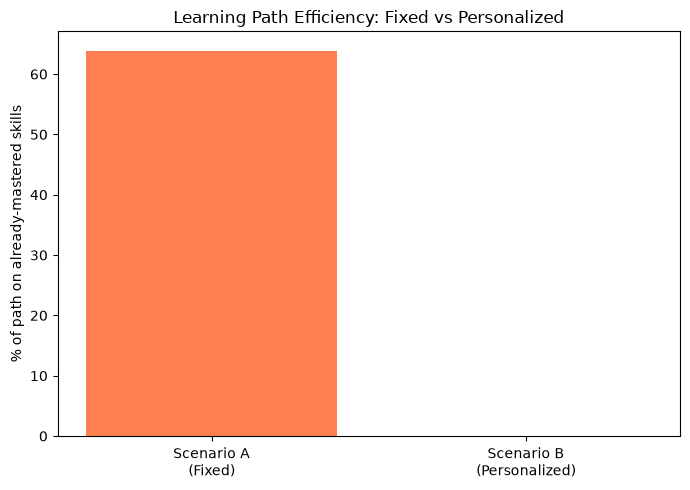

In [8]:
# Cell 8 — Bar chart: wasted effort A vs B
plt.figure(figsize=(7, 5))
plt.bar(['Scenario A\n(Fixed)', 'Scenario B\n(Personalized)'],
        [scenario_a_waste, scenario_b_waste],
        color=['coral', 'steelblue'])
plt.ylabel('% of path on already-mastered skills')
plt.title('Learning Path Efficiency: Fixed vs Personalized')
plt.tight_layout()
plt.savefig('../outputs/figures/scenario_comparison.png', dpi=150)
plt.show()

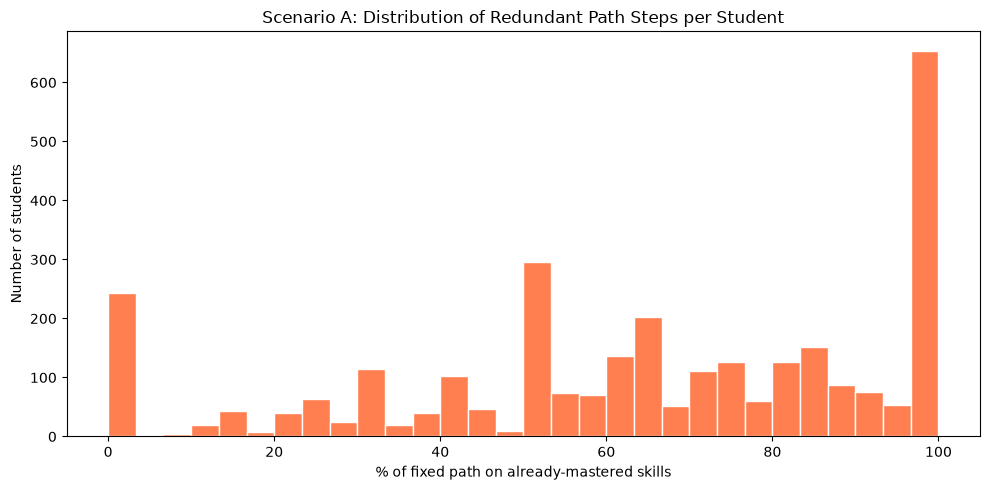

In [9]:
# Cell 9 — Distribution of wasted effort across students (Scenario A)
plt.figure(figsize=(10, 5))
plt.hist(waste_df['pct_wasted'], bins=30,
         color='coral', edgecolor='white')
plt.xlabel('% of fixed path on already-mastered skills')
plt.ylabel('Number of students')
plt.title('Scenario A: Distribution of Redundant Path Steps per Student')
plt.tight_layout()
plt.savefig('../outputs/figures/wasted_effort_distribution.png', dpi=150)
plt.show()

## SECTION 7 — LLM Explanation Layer (Teacher-in-the-Loop)

**Why:** Template-based explanations show the teacher-in-the-loop design — each recommendation comes with a plain-language justification for teacher review rather than being a black-box automated decision.

**Thesis note:** "To support the teacher-in-the-loop design, each recommendation was accompanied by a plain-language explanation derived from the learner's mastery estimate. These explanations are presented as draft suggestions for teacher review rather than automated decisions."

In [10]:
# Cell 10 — Template-based explanation (teacher-in-the-loop)
def explain_recommendation(row):
    return (
        f"Student shows low estimated mastery ({row['mastery_prob']:.0%}) "
        f"on '{row['recommended_skill']}'. Recommend revisiting this "
        f"skill before progressing. (Teacher review required.)"
    )

sample_rec = recommendations_df.iloc[0]
print(explain_recommendation(sample_rec))

Student shows low estimated mastery (13%) on 'Median'. Recommend revisiting this skill before progressing. (Teacher review required.)


## SECTION 8 — Save Recommendations

In [11]:
# Cell 11 — Save recommendations and scenario comparison
recommendations_df['explanation'] = recommendations_df.apply(
    lambda r: explain_recommendation(
        {'mastery_prob': r['mastery_prob'],
         'recommended_skill': r['recommended_skill']}), axis=1)

recommendations_df.to_csv('../outputs/recommendations.csv', index=False)
waste_df.to_csv('../outputs/scenario_comparison.csv', index=False)

print("Saved recommendations.csv and scenario_comparison.csv")
print(f"\nFinal summary:")
print(f"  Students with recommendations: {recommendations_df['user_id'].nunique()}")
print(f"  Total recommendations: {len(recommendations_df)}")
print(f"  Scenario A wasted effort: {scenario_a_waste:.1f}%")
print(f"  Scenario B wasted effort: {scenario_b_waste:.1f}%")

Saved recommendations.csv and scenario_comparison.csv

Final summary:
  Students with recommendations: 2419
  Total recommendations: 7770
  Scenario A wasted effort: 63.9%
  Scenario B wasted effort: 0.0%
